<a href="https://colab.research.google.com/github/MajorTomTom792/miRNA-analysis/blob/main/SAM_tools.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from collections import defaultdict
from typing import NamedTuple
!pip install pysam
!pip install Biopython
import Bio
from Bio import SeqIO
import pysam
import pandas as pd
import re
import random
from collections import Counter

#should filter sequence on occurrence frequency

deletion = {item: 0 for item in ['A', 'T', 'G', 'C']}
substitution = {'A-T': 0, 'A-G': 0, 'A-C': 0, 'T-A': 0, 'T-G': 0, 'T-C': 0, 'G-A': 0, 'G-T': 0, 'G-C': 0, 'C-A': 0, 'C-T': 0, 'C-G': 0, 'Total': 0}
locationOccurrence = {item: 0 for item in range(1, 26)}
Name_of_mutant_seq = defaultdict(int)


#set up of the functions

##gives the number of sequences in each miR family
def num_process(query):
  query = int(query.split('x')[-1])
  return query
##extract SAM file info from a given SAM file
def samAnalyzer(inputFile):
  seqInfo_base_on_length = [[] for _ in range(8)]
  numCount = {}
  samfile = pysam.AlignmentFile(inputFile, 'r')
  for read in samfile.fetch(until_eof=True):
    if not str(read.reference_name) == 'None' and 'Seq' in str(read.qname) and int(read.mapq) == 255:
      length = len(str(read.seq))
      samInfo = [str(read.reference_name), str(read.qname), str(read.seq),str(read.get_tag('MD')), length, num_process(str(read.qname))]
      filterLengths(samInfo, seqInfo_base_on_length)
  return seqInfo_base_on_length

#0 is miR name, 1 is query number, 2 is query sequence, 3 is mutation deletion
#filter lengths by 18-25 individually
def filterLengths(samInfo, seqInfo_base_on_length):
  length = samInfo[4]
  if 18 <= length <= 25:
    seqInfo_base_on_length[length - 18].append(samInfo)
#mismatch analyzer

#localMutation for bootstrap, location of mutation, also outputs total mutation and miR count mutation
def SequentialAnalysis(seqInfoList, outputFileName, mutationLocation, eventType):
  split = []
  totalSplit = []
  weight = []
  with open(outputFileName, 'w') as f:
    for items in seqInfoList:
      mutationLocation = {item: 0 for item in range(1, 26)}
      eventType = {'A-T': 0, 'A-G': 0, 'A-C': 0, 'T-A': 0, 'T-G': 0, 'T-C': 0, 'G-A': 0, 'G-T': 0, 'G-C': 0, 'C-A': 0, 'C-T': 0, 'C-G': 0, 'Total': 0}
      #seqInfo = [ref name, qname, read seq, MD tag, length, occurrence]
      for seqInfo in items:
        length = seqInfo[4]
        mismatchAnalyzer = get_mismatches(seqInfo[3], seqInfo[2], eventType, Name_of_mutant_seq, seqInfo[5], seqInfo[0], mutationLocation)
        split.append(mismatchAnalyzer[0])
        weight.append(seqInfo[5])
      f.write(f'Substitution event count for {seqInfo[4]} long miRNA sequences: {eventType}\n')
      f.write(f'Position event count for {seqInfo[4]} long miRNA sequences: {mutationLocation}\n')
      totalSplit.append([eventType, mutationLocation, Name_of_mutant_seq])
    return [totalSplit, split, weight]

#determines mismatches, its location, the sequence, and what event type
def get_mismatches(md, seq, sequenceDictionary, NumMutationBYName, query, sequenceName, mutationLocation):
    bootstrapMutationInfo = {'A-T': 0, 'A-G': 0, 'A-C': 0, 'T-A': 0, 'T-G': 0, 'T-C': 0, 'G-A': 0, 'G-T': 0, 'G-C': 0, 'C-A': 0, 'C-T': 0, 'C-G': 0, 'Total': 0}
    i = 0
    #finds for digit, then a letter or ^
    tokens = re.findall(r'\d+|^[A-Z]+|[A-Z]', md)
    for token in tokens:
        if token.isdigit():
            i += int(token)
        elif token.startswith('^'):
            continue
        elif token != seq[i]:
            ref_base = token
            read_base = seq[i]
            if ref_base != read_base and read_base != 'N':
                NumMutationBYName[sequenceName] += query
                sequenceDictionary[str(ref_base) + '-' + str(read_base)] += query
                bootstrapMutationInfo[str(ref_base) + '-' + str(read_base)] += 1
                mutationLocation[i+1] += query
            sequenceDictionary['Total'] += query
            bootstrapMutationInfo['Total'] += 1
            i += 1
    return [bootstrapMutationInfo, mutationLocation]

#bootstrap
def error_bootstrap(lists, weights, rounds):
  metadata = []
  nameInputs = input('Control or High: ')
  csv = pd.DataFrame(index=['A-T', 'A-G', 'A-C', 'T-A', 'T-G', 'T-C',  'G-A', 'G-T', 'G-C', 'C-A', 'C-T', 'C-G', 'Total']) #, 'Insertions', 'Deletions'])
  csv.index.name = 'Types of Editing'
  for i in range(rounds):
    metadata.append(nameInputs)
    bootstrapped_total_reads = 300000
    randomSelection = random.choices(lists, weights=weights, k=bootstrapped_total_reads)
    A_T = sum(item['A-T'] for item in randomSelection)
    A_G = sum(item['A-G'] for item in randomSelection)
    A_C = sum(item['A-C'] for item in randomSelection)
    T_A = sum(item['T-A'] for item in randomSelection)
    T_G = sum(item['T-G'] for item in randomSelection)
    T_C = sum(item['T-C'] for item in randomSelection)
    G_A = sum(item['G-A'] for item in randomSelection)
    G_T = sum(item['G-T'] for item in randomSelection)
    G_C = sum(item['G-C'] for item in randomSelection)
    C_A = sum(item['C-A'] for item in randomSelection)
    C_T = sum(item['C-T'] for item in randomSelection)
    C_G = sum(item['C-G'] for item in randomSelection)
    Total = sum(item['Total'] for item in randomSelection)
    csv[str(nameInputs) + str(int(i)+1)] = [A_T, A_G, A_C, T_A, T_G, T_C, G_A, G_T, G_C, C_A, C_T, C_G, Total]
  csv.to_csv('edits.csv', index=True)

In [ ]:
splitLength = []
mmu_mature1 = '/content/mmu_mature.fa'
samFile = '/content/bowtieControlPlastic.sam'
splitLength = samAnalyzer(samFile)
sequenceAnalysisInfo = SequentialAnalysis(splitLength, 'controlPlastic', locationOccurrence, substitution)
#print(sequenceAnalysisInfo[1])
error_bootstrap(sequenceAnalysisInfo[1], sequenceAnalysisInfo[2], 50)

Control or High: Control


['Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control',
 'Control']

In [ ]:
splitLength = []
mmu_mature1 = '/content/mmu_mature.fa'
samFile = '/content/bowtieHigh.sam'
splitLength = samAnalyzer(samFile)
sequenceAnalysisInfo = SequentialAnalysis(splitLength, 'highPlastic', locationOccurrence, substitution)
error_bootstrap(sequenceAnalysisInfo[1], sequenceAnalysisInfo[2], 50)

Control or High: High


['High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High',
 'High']

In [ ]:
import heapq
top_20 = dict(heapq.nlargest(20, Name_of_mutant_seq.items(), key=lambda item: item[1]))

[]
[]


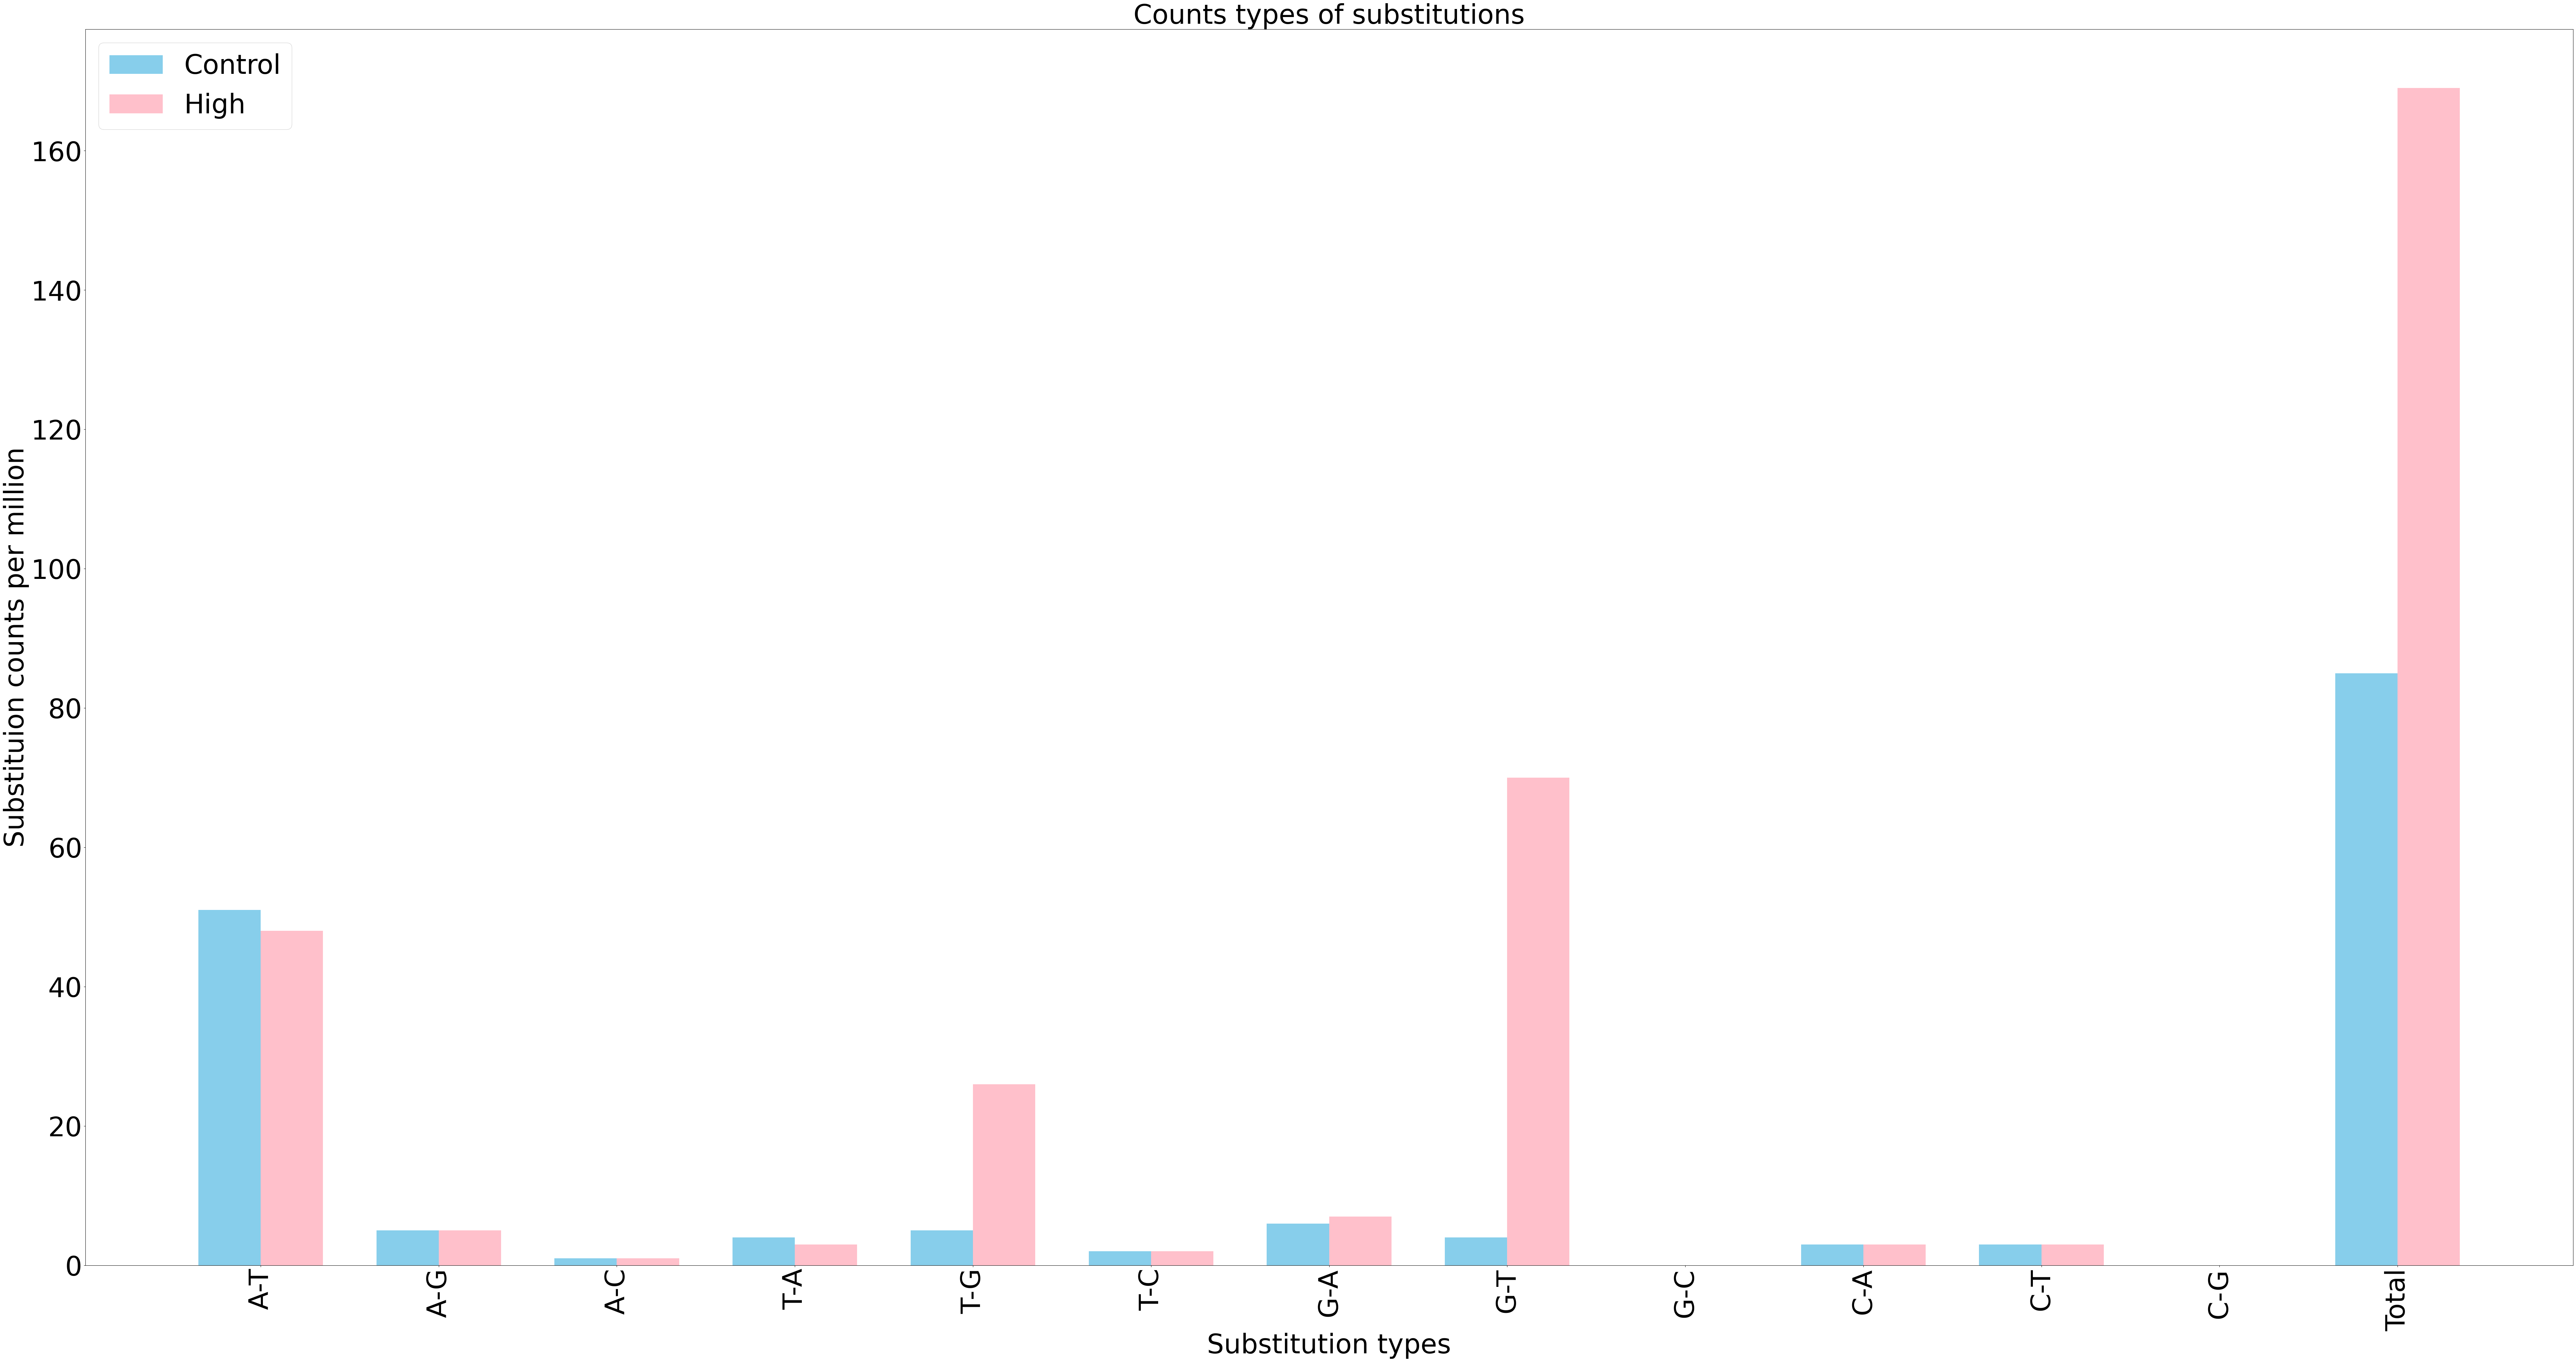

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
errorBarsControl = []
errorBarsHigh = []
control = {'A-T': 2591, 'A-G': 273, 'A-C': 42, 'T-A': 187, 'T-G': 270, 'T-C': 96, 'G-A': 325, 'G-T': 222, 'G-C': 15, 'C-A': 145, 'C-T': 143, 'C-G': 23, 'Total': 4348}
high = {'A-T': 2886, 'A-G': 322, 'A-C': 89, 'T-A': 207, 'T-G': 1547, 'T-C': 112, 'G-A': 399, 'G-T': 4255, 'G-C': 23, 'C-A': 153, 'C-T': 156, 'C-G': 27, 'Total': 10198}

def expected_tech_error(total_seq, avgLen):
  Evalue = 0.001*total_seq*avgLen
  return Evalue

for key, values in control.items():
  control[key] = normalization(round(values/3), totalControl)
for key, values in high.items():
  high[key] = normalization(round(values/3), totalHigh)
'''
samfile = pysam.AlignmentFile('/content/bowtieControlPlastic.sam', 'r')
summation = []
header = samfile.header
#print(header)
for stuff in header['SQ']:
  summation.append(int(stuff['LN']))
summation = round(sum(summation)/len(summation))
for key, values, in control.items():
  errorBarsControl.append(round((values)*(expected_tech_error(round(16992980/3), summation)/1424910)))

samfile = pysam.AlignmentFile('/content/bowtieHigh.sam', 'r')
summation = []
header = samfile.header
#print(header)
for stuff in header['SQ']:
  summation.append(int(stuff['LN']))
summation = round(sum(summation)/len(summation))
for key, values, in high.items():
  errorBarsHigh.append(round((values)*(expected_tech_error(round(20165628/3), summation)/3325876)))
'''
print(errorBarsControl)
print(errorBarsHigh)

Controlupper_errors = np.zeros_like(errorBarsControl)
Controlasymmetric_y_err = [errorBarsControl, Controlupper_errors]
Highupper_errors = np.zeros_like(errorBarsHigh)
Highasymmetric_y_err = [errorBarsHigh, Highupper_errors]


positions = list(control.keys())

control_vals = list(control.values())
high_vals = list(high.values())

x = np.arange(len(positions))

width = 0.35

plt.figure(figsize=(100,50))

plt.bar(x - width/2, control_vals, width, label='Control', color='skyblue')#, yerr=Controlasymmetric_y_err, capsize=50, ecolor='Black')
plt.bar(x + width/2, high_vals, width, label='High', color='Pink')#, yerr=Highasymmetric_y_err, capsize=50, ecolor='Black')
#plt.bar(categories, values, yerr=errors, capsize=5, color='skyblue', ecolor='black')
plt.xticks(x, positions, fontsize=60, rotation=90)
plt.yticks(fontsize=60)
plt.xlabel('Substitution types', fontsize=60)
plt.ylabel('Substituion counts per million', fontsize=60)
plt.title('Counts types of substitutions', fontsize=60)
plt.legend(fontsize=60)

plt.show()